# Feature Engineering for DO Early Warning Model

**Data sources:**
- `data/data_campaign_flat_clean.csv` — 17 campaign ponds (15-min DO, pH, water temp), Nov 2025 – Jan 2026
- `data/open_meteo_24.csv` — Hourly weather for Eluru, Jun 2021 – Feb 2026

**Goals:**
1. Design an outcome variable: worst ~15–20% of days by morning DO across ponds
2. Engineer candidate features from weather + pond time series
3. Rank all features by Spearman/Pearson correlation with the outcome
4. Identify the best feature set for downstream ML

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. Load & Prepare Data

In [2]:
CAMPAIGN_THRESHOLD = 2.176

# ── Pond data (campaign) ──────────────────────────────────────────────────
dc = pd.read_csv('data/data_campaign_flat_clean.csv')
dc['date'] = pd.to_datetime(dc['date'])
dc['datetime'] = pd.to_datetime(dc['date'].astype(str) + ' ' + dc['time'])
dc['hour'] = dc['datetime'].dt.hour

print(f"Campaign: {len(dc):,} rows, {dc['pond_id'].nunique()} ponds, "
      f"{dc['date'].nunique()} days ({dc['date'].min().date()} → {dc['date'].max().date()})")

# ── Weather (Eluru only) ──────────────────────────────────────────────────
wx = pd.read_csv('data/open_meteo_24.csv')
wx['time'] = pd.to_datetime(wx['time'])
wx = wx[wx['region'] == 'Eluru'].copy().sort_values('time').reset_index(drop=True)
wx['date'] = wx['time'].dt.normalize()
wx['hour'] = wx['time'].dt.hour

print(f"Weather: {len(wx):,} hourly rows ({wx['time'].min()} → {wx['time'].max()})")
print(f"Overlap period: {dc['date'].min().date()} → {dc['date'].max().date()}")

Campaign: 67,329 rows, 17 ponds, 64 days (2025-11-28 → 2026-01-30)
Weather: 40,968 hourly rows (2021-06-15 00:00:00 → 2026-02-15 23:00:00)
Overlap period: 2025-11-28 → 2026-01-30


In [3]:
# ── Pond data (campaign) ──────────────────────────────────────────────────
dc = pd.read_csv('data/data_campaign_flat_clean.csv')
dc['date'] = pd.to_datetime(dc['date'])
dc['datetime'] = pd.to_datetime(dc['date'].astype(str) + ' ' + dc['time'])
dc['hour'] = dc['datetime'].dt.hour

print(f"Campaign: {len(dc):,} rows, {dc['pond_id'].nunique()} ponds, "
      f"{dc['date'].nunique()} days ({dc['date'].min().date()} → {dc['date'].max().date()})")

# ── Weather (Eluru only) ──────────────────────────────────────────────────
wx = pd.read_csv('data/open_meteo_24.csv')
wx['time'] = pd.to_datetime(wx['time'])
wx = wx[wx['region'] == 'Eluru'].copy().sort_values('time').reset_index(drop=True)
wx['date'] = wx['time'].dt.normalize()
wx['hour'] = wx['time'].dt.hour

print(f"Weather: {len(wx):,} hourly rows ({wx['time'].min()} → {wx['time'].max()})")
print(f"Overlap period: {dc['date'].min().date()} → {dc['date'].max().date()}")

Campaign: 67,329 rows, 17 ponds, 64 days (2025-11-28 → 2026-01-30)
Weather: 40,968 hourly rows (2021-06-15 00:00:00 → 2026-02-15 23:00:00)
Overlap period: 2025-11-28 → 2026-01-30


## 2. Outcome Variable Design

Use the **5–8 AM morning window** (when DO is lowest) across all 17 campaign ponds.

For each day compute:
- `mean_do`: mean of pond-level morning DO means
- `frac_low`: fraction of ponds with morning mean DO < 3 mg/L
- `bad_day`: binary — 1 when the day is in the worst ~15–20%

We'll use a **continuous outcome** (`mean_do`) for correlation analysis and a
**binary outcome** (`bad_day`) defined as the bottom 20th-percentile of `mean_do`
across campaign days. This captures days where DO is broadly poor.

In [4]:
# ── Morning window: 5–8 AM ────────────────────────────────────────────────
morning = dc[dc['hour'].between(5, 8)].copy()

# Per-pond per-day morning aggregates
pond_day = morning.groupby(['pond_id', 'date']).agg(
    morning_do=('do_mg_l', 'mean'),
    morning_temp=('temperature_c', 'mean'),
    morning_ph=('ph', 'mean'),
    do_min=('do_mg_l', 'min'),
    do_std=('do_mg_l', 'std'),
    n_obs=('do_mg_l', 'count'),
).reset_index()


In [5]:

# Day-level aggregation
day_outcome = pond_day.groupby('date').agg(
    n_ponds=('pond_id', 'nunique'),
    mean_do=('morning_do', 'mean'),
    median_do=('morning_do', 'median'),
    std_do=('morning_do', 'std'),
    min_do=('morning_do', 'min'),
    p25_do=('morning_do', lambda x: np.percentile(x, 25)),
    n_low=('morning_do', lambda x: (x < CAMPAIGN_THRESHOLD).sum()),
    mean_temp=('morning_temp', 'mean'),
    mean_ph=('morning_ph', 'mean'),
).reset_index()

day_outcome['frac_low'] = day_outcome['n_low'] / day_outcome['n_ponds']

# Restrict to days with >= 5 ponds (stable estimates)
day_outcome = day_outcome[day_outcome['n_ponds'] >= 5].copy()

# Binary outcome: worst 20% of days by mean_do
threshold_20 = np.percentile(day_outcome['mean_do'], 20)
day_outcome['bad_day'] = (day_outcome['mean_do'] <= threshold_20).astype(int)

print(f"Day-level outcome: {len(day_outcome)} days (>= 5 ponds)")
print(f"mean_do 20th-percentile threshold: {threshold_20:.2f} mg/L")
print(f"bad_day rate: {day_outcome['bad_day'].mean():.1%} ({day_outcome['bad_day'].sum()}/{len(day_outcome)})")
print(f"\nFor comparison — frac_low thresholds:")
for t in [0.5, 0.6, 0.7, 0.75, 0.8]:
    n = (day_outcome['frac_low'] >= t).sum()
    print(f"  frac_low >= {t}: {n}/{len(day_outcome)} = {n/len(day_outcome):.1%}")

day_outcome[['date', 'n_ponds', 'mean_do', 'frac_low', 'bad_day']].describe()

Day-level outcome: 55 days (>= 5 ponds)
mean_do 20th-percentile threshold: 2.14 mg/L
bad_day rate: 20.0% (11/55)

For comparison — frac_low thresholds:
  frac_low >= 0.5: 27/55 = 49.1%
  frac_low >= 0.6: 14/55 = 25.5%
  frac_low >= 0.7: 3/55 = 5.5%
  frac_low >= 0.75: 3/55 = 5.5%
  frac_low >= 0.8: 1/55 = 1.8%


,date,n_ponds,mean_do,frac_low,bad_day
count,55,55.000000,55.000000,55.000000,55.000000
mean,2026-01-02 14:50:10.909091,13.563636,2.637020,0.463786,0.200000
min,2025-12-04 00:00:00,5.000000,1.181760,0.000000,0.000000
25%,2025-12-20 12:00:00,14.000000,2.255426,0.333333,0.000000
50%,2026-01-03 00:00:00,15.000000,2.596585,0.466667,0.000000
75%,2026-01-16 12:00:00,15.500000,2.987036,0.585714,0.000000
max,2026-01-30 00:00:00,16.000000,3.878380,0.800000,1.000000
std,NaN,3.425199,0.553473,0.169231,0.403687


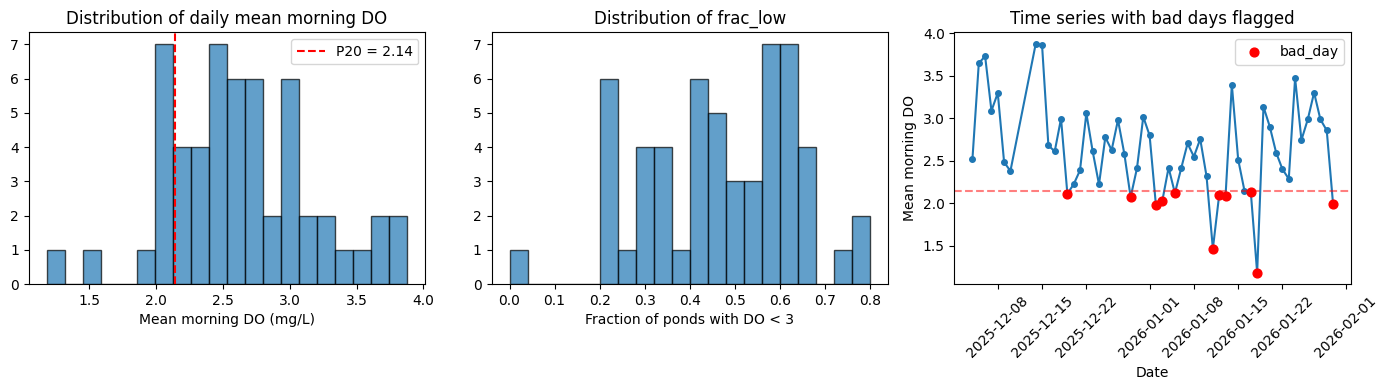

Saved to plots_rd1/feature_eng/outcome_distributions.png


In [6]:
# Visualize outcome distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(day_outcome['mean_do'], bins=20, edgecolor='k', alpha=0.7)
axes[0].axvline(threshold_20, color='r', ls='--', label=f'P20 = {threshold_20:.2f}')
axes[0].set_xlabel('Mean morning DO (mg/L)')
axes[0].set_title('Distribution of daily mean morning DO')
axes[0].legend()

axes[1].hist(day_outcome['frac_low'], bins=20, edgecolor='k', alpha=0.7)
axes[1].set_xlabel('Fraction of ponds with DO < 3')
axes[1].set_title('Distribution of frac_low')

axes[2].plot(day_outcome['date'], day_outcome['mean_do'], 'o-', ms=4)
bad_days = day_outcome[day_outcome['bad_day'] == 1]
axes[2].scatter(bad_days['date'], bad_days['mean_do'], c='red', zorder=5, s=40, label='bad_day')
axes[2].axhline(threshold_20, color='r', ls='--', alpha=0.5)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Mean morning DO')
axes[2].set_title('Time series with bad days flagged')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots_rd1/feature_eng/outcome_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots_rd1/feature_eng/outcome_distributions.png")

## 3. Weather Feature Engineering

### Feature groups:
1. **Overnight (0–6 AM)** — conditions during oxygen depletion
2. **Early morning (6–8 AM)** — instantaneous at measurement time
3. **Night wind (19:00 prev → 06:00)** — reaeration window
4. **Prior day (06–19 prev day)** — daytime photosynthesis & precip
5. **3-day rolling** — cumulative weather effects
6. **Weather regime** — categorical rule-based

In [7]:
# ── Restrict weather to campaign overlap period ────────────────────────────
# Need a few days before the first campaign day for lag features
wx_start = day_outcome['date'].min() - pd.Timedelta(days=4)
wx_end = day_outcome['date'].max() + pd.Timedelta(days=1)
wxc = wx[(wx['time'] >= wx_start) & (wx['time'] < wx_end)].copy()
print(f"Weather subset: {len(wxc)} hourly rows for {wx_start.date()} → {wx_end.date()}")

# Rename for convenience
wxc = wxc.rename(columns={
    'temperature_2m': 'temp',
    'relative_humidity_2m': 'rh',
    'dew_point_2m': 'dewpoint',
    'vapor_pressure_deficit': 'vpd',
    'wind_speed_10m': 'wind',
    'wind_direction_10m': 'wind_dir',
    'shortwave_radiation': 'sw_rad',
    'direct_radiation': 'dir_rad',
    'surface_pressure': 'pressure',
    'et0_fao_evapotranspiration': 'et0',
})

Weather subset: 1488 hourly rows for 2025-11-30 → 2026-01-31


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# GROUP 1: Overnight features (0:00–6:00 AM of measurement day)
# ═══════════════════════════════════════════════════════════════════════════
overnight = wxc[wxc['hour'].between(0, 5)].copy()  # hours 0,1,2,3,4,5

g1 = overnight.groupby('date').agg(
    overnight_temp_mean=('temp', 'mean'),
    overnight_temp_min=('temp', 'min'),
    overnight_rh_mean=('rh', 'mean'),
    overnight_rh_max=('rh', 'max'),
    overnight_wind_mean=('wind', 'mean'),
    overnight_wind_min=('wind', 'min'),
    overnight_vpd_mean=('vpd', 'mean'),
    overnight_precip_sum=('precipitation', 'sum'),
    overnight_dewpoint_mean=('dewpoint', 'mean'),
    overnight_pressure_mean=('pressure', 'mean'),
).reset_index()

print(f"Group 1 (overnight 0-6AM): {len(g1)} days, {len(g1.columns)-1} features")

# ═══════════════════════════════════════════════════════════════════════════
# GROUP 2: Early morning snapshot (6–8 AM)
# ═══════════════════════════════════════════════════════════════════════════
early_morning = wxc[wxc['hour'].between(6, 8)].copy()

g2 = early_morning.groupby('date').agg(
    am_temp_mean=('temp', 'mean'),
    am_rh_mean=('rh', 'mean'),
    am_wind_mean=('wind', 'mean'),
    am_vpd_mean=('vpd', 'mean'),
    am_sw_rad_mean=('sw_rad', 'mean'),
    am_pressure_mean=('pressure', 'mean'),
    am_precip_sum=('precipitation', 'sum'),
).reset_index()

print(f"Group 2 (6-8AM): {len(g2)} days, {len(g2.columns)-1} features")

# ═══════════════════════════════════════════════════════════════════════════
# GROUP 3: Night reaeration window (19:00 prev day → 06:00 measurement day)
# ═══════════════════════════════════════════════════════════════════════════
night_reaeration = wxc[(wxc['hour'] >= 19) | (wxc['hour'] < 6)].copy()
# Assign to the calendar day whose 06:00 closes the window
night_reaeration['target_date'] = night_reaeration['date'].copy()
night_reaeration.loc[night_reaeration['hour'] >= 19, 'target_date'] += pd.Timedelta(days=1)

g3 = night_reaeration.groupby('target_date').agg(
    night_wind_mean=('wind', 'mean'),
    night_wind_min=('wind', 'min'),
    night_wind_max=('wind', 'max'),
    night_temp_mean=('temp', 'mean'),
    night_temp_range=('temp', lambda x: x.max() - x.min()),
    night_rh_mean=('rh', 'mean'),
    night_vpd_mean=('vpd', 'mean'),
    night_precip_sum=('precipitation', 'sum'),
).reset_index().rename(columns={'target_date': 'date'})

print(f"Group 3 (night 19-06): {len(g3)} days, {len(g3.columns)-1} features")

# ═══════════════════════════════════════════════════════════════════════════
# GROUP 4: Prior daytime (06:00–19:00 of previous day)
# ═══════════════════════════════════════════════════════════════════════════
daytime = wxc[wxc['hour'].between(6, 18)].copy()  # 06:00-18:59

g4_raw = daytime.groupby('date').agg(
    prev_day_temp_max=('temp', 'max'),
    prev_day_temp_mean=('temp', 'mean'),
    prev_day_sw_sum=('sw_rad', 'sum'),
    prev_day_dir_rad_sum=('dir_rad', 'sum'),
    prev_day_precip_sum=('precipitation', 'sum'),
    prev_day_vpd_max=('vpd', 'max'),
    prev_day_vpd_mean=('vpd', 'mean'),
    prev_day_wind_mean=('wind', 'mean'),
    prev_day_rh_mean=('rh', 'mean'),
    prev_day_et0_sum=('et0', 'sum'),
).reset_index()

# Shift forward by 1 day (these are features for the NEXT day's morning)
g4 = g4_raw.copy()
g4['date'] = g4['date'] + pd.Timedelta(days=1)

print(f"Group 4 (prev daytime): {len(g4)} days, {len(g4.columns)-1} features")

Group 1 (overnight 0-6AM): 62 days, 10 features
Group 2 (6-8AM): 62 days, 7 features
Group 3 (night 19-06): 63 days, 8 features
Group 4 (prev daytime): 62 days, 10 features


In [9]:

# ═══════════════════════════════════════════════════════════════════════════
# GROUP 5: Multi-day rolling features (3-day window)
# ═══════════════════════════════════════════════════════════════════════════

# First build full-day aggregates
day_wx = wxc.groupby('date').agg(
    day_temp_mean=('temp', 'mean'),
    day_temp_max=('temp', 'max'),
    day_temp_min=('temp', 'min'),
    day_rh_mean=('rh', 'mean'),
    day_wind_mean=('wind', 'mean'),
    day_precip_sum=('precipitation', 'sum'),
    day_sw_sum=('sw_rad', 'sum'),
    day_vpd_mean=('vpd', 'mean'),
    day_et0_sum=('et0', 'sum'),
    day_pressure_mean=('pressure', 'mean'),
    day_weather_code_mode=('weather_code', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan),
).reset_index().sort_values('date')

# 3-day rolling (including current day, so prior 2 days + today)
# Use shift(1) for strictly prior 3 days (lag1, lag2, lag3)
roll_cols = ['day_temp_mean', 'day_rh_mean', 'day_wind_mean', 'day_precip_sum',
             'day_sw_sum', 'day_vpd_mean', 'day_et0_sum']

g5 = day_wx[['date']].copy()

for col in roll_cols:
    base = col.replace('day_', '')
    if 'sum' in col:
        # For sums, use rolling sum
        g5[f'roll3d_{base}'] = day_wx[col].rolling(3, min_periods=3).sum().values
    else:
        # For means, use rolling mean
        g5[f'roll3d_{base}'] = day_wx[col].rolling(3, min_periods=3).mean().values

# Temperature range over 3 days
g5['roll3d_temp_range'] = (
    day_wx['day_temp_max'].rolling(3, min_periods=3).max().values -
    day_wx['day_temp_min'].rolling(3, min_periods=3).min().values
)

# Precipitation lag features (strictly prior-day: no current-day leakage)
g5['precip_lag1'] = day_wx['day_precip_sum'].shift(1).values
g5['precip_lag2'] = day_wx['day_precip_sum'].shift(2).values

# 2-day precipitation sum using only lag-1 and lag-2 (no current day)
# Rationale: current-day precipitation cannot be known before the 5-8 AM DO
# measurement, so we define the 2-day rolling window as ending 24 hours ago.
g5['precip_2d_sum'] = (
    day_wx['day_precip_sum'].shift(1) + day_wx['day_precip_sum'].shift(2)
).values

# 3-day precipitation sum also shifted to exclude current day (ending 24h ago)
g5['roll3d_precip_sum'] = (
    day_wx['day_precip_sum'].rolling(3, min_periods=3).sum().shift(1).values
)

# Shortwave lag
g5['sw_sum_lag1'] = day_wx['day_sw_sum'].shift(1).values

# Diurnal temperature range (same day)
g5['diurnal_temp_range'] = (day_wx['day_temp_max'] - day_wx['day_temp_min']).values

print(f"Group 5 (rolling/lag): {len(g5)} days, {len(g5.columns)-1} features")

# ═══════════════════════════════════════════════════════════════════════════
# GROUP 6: Weather regime (categorical)
# ═══════════════════════════════════════════════════════════════════════════
# Based on 3-day rolling values
g6 = g5[['date']].copy()

# Cloud proxy: weather_code. Codes >= 40 are fog/rain/snow, >= 60 drizzle, >= 80 showers
# Use a simple proxy: high rh + low sw = overcast
# Rules (evaluated in order):
#   if 3-day precip > 5 mm → Rainy (2)
#   elif 3-day rh > 75% AND 3-day temp > 28°C → Hot-Humid (0)
#   elif 3-day sw < P25 (low sunshine) → Overcast (3)
#   else → Cool-Dry (1)

sw_p25 = g5['roll3d_sw_sum'].quantile(0.25)

conditions = [
    g5['roll3d_precip_sum'] > 5,                                              # Rainy
    (g5['roll3d_rh_mean'] > 75) & (g5['roll3d_temp_mean'] > 28),             # Hot-Humid
    g5['roll3d_sw_sum'] < sw_p25,                                             # Overcast
]
choices = [2, 0, 3]
g6['weather_regime'] = np.select(conditions, choices, default=1)  # default Cool-Dry

print(f"\nWeather regime distribution:")
regime_names = {0: 'Hot-Humid', 1: 'Cool-Dry', 2: 'Rainy', 3: 'Overcast'}
for code, name in regime_names.items():
    n = (g6['weather_regime'] == code).sum()
    print(f"  {name} ({code}): {n} days")


Group 5 (rolling/lag): 62 days, 13 features

Weather regime distribution:
  Hot-Humid (0): 0 days
  Cool-Dry (1): 46 days
  Rainy (2): 4 days
  Overcast (3): 12 days


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# GROUP 7: Pond-derived features (aggregated across all 17 ponds)
# ═══════════════════════════════════════════════════════════════════════════

# Overnight pond conditions (all hours, not just morning)
dc_night = dc[dc['hour'].between(0, 5)].copy()
pond_night = dc_night.groupby(['pond_id', 'date']).agg(
    overnight_pond_do_mean=('do_mg_l', 'mean'),
    overnight_pond_temp_mean=('temperature_c', 'mean'),
    overnight_pond_ph_mean=('ph', 'mean'),
).reset_index()

# Day-level pond overnight aggregates
g7a = pond_night.groupby('date').agg(
    pond_overnight_do_mean=('overnight_pond_do_mean', 'mean'),
    pond_overnight_do_std=('overnight_pond_do_mean', 'std'),
    pond_overnight_temp_mean=('overnight_pond_temp_mean', 'mean'),
    pond_overnight_ph_mean=('overnight_pond_ph_mean', 'mean'),
).reset_index()

# Prior afternoon/evening pond conditions (12-20 of previous day)
dc_eve = dc[dc['hour'].between(12, 20)].copy()
pond_eve = dc_eve.groupby(['pond_id', 'date']).agg(
    eve_do_mean=('do_mg_l', 'mean'),
    eve_do_max=('do_mg_l', 'max'),
    eve_temp_mean=('temperature_c', 'mean'),
).reset_index()

g7b_raw = pond_eve.groupby('date').agg(
    prev_eve_do_mean=('eve_do_mean', 'mean'),
    prev_eve_do_max=('eve_do_max', 'max'),
    prev_eve_temp_mean=('eve_temp_mean', 'mean'),
).reset_index()
# Shift: these are features for the next day's morning
g7b = g7b_raw.copy()
g7b['date'] = g7b['date'] + pd.Timedelta(days=1)

# DO trend: day-over-day change in mean morning DO (from outcome)
g7c = day_outcome[['date', 'mean_do']].copy().sort_values('date')
g7c['do_change_1d'] = g7c['mean_do'].diff()
g7c['do_change_2d'] = g7c['mean_do'].diff(2)
# Rolling 3-day mean of morning DO (as a "recent DO baseline")
g7c['do_roll3d_mean'] = g7c['mean_do'].rolling(3, min_periods=2).mean()
g7c = g7c.drop(columns=['mean_do'])

print(f"Group 7a (pond overnight): {len(g7a)} days, {len(g7a.columns)-1} features")
print(f"Group 7b (prev evening): {len(g7b)} days, {len(g7b.columns)-1} features")
print(f"Group 7c (DO trend): {len(g7c)} days, {len(g7c.columns)-1} features")

Group 7a (pond overnight): 63 days, 4 features
Group 7b (prev evening): 63 days, 3 features
Group 7c (DO trend): 55 days, 3 features


In [11]:

# ═══════════════════════════════════════════════════════════════════════════
# GROUP 9: Historical pond aggregate trends — strictly prior to 48 h
# Window: [target_date − 7 days, target_date − 2 days)
# Features: mean, std, Q25, linear slope of DO / pH / water-temp per day;
#           fraction of all 15-min readings with DO < 3 (stress prevalence).
# These are autoregressive features safe for forecasting (no same-day leakage).
# ═══════════════════════════════════════════════════════════════════════════
from scipy.stats import linregress

HIST_WINDOW_DAYS = 5   # days of history to use, ending 48 h before measurement

pond_trend_rows = []
for target_date in day_outcome['date']:
    cutoff_end   = pd.Timestamp(target_date) - pd.Timedelta(hours=48)
    cutoff_start = cutoff_end - pd.Timedelta(days=HIST_WINDOW_DAYS)

    mask   = (dc['datetime'] >= cutoff_start) & (dc['datetime'] < cutoff_end)
    subset = dc[mask].copy()

    row = {'date': target_date}
    if len(subset) >= 30:
        for col, tag in [('do_mg_l', 'do'), ('ph', 'ph'), ('temperature_c', 'wtemp')]:
            vals = subset[col].dropna()
            row[f'hist_{tag}_mean'] = vals.mean()
            row[f'hist_{tag}_std']  = vals.std()
            row[f'hist_{tag}_q25']  = vals.quantile(0.25)

            # Linear slope over daily means (units per day)
            daily = subset.groupby('date')[col].mean()
            if len(daily) >= 3:
                x = np.arange(len(daily), dtype=float)
                slope, _, _, _, _ = linregress(x, daily.values)
                row[f'hist_{tag}_slope'] = slope

        # Fraction of 15-min obs in window with DO < 3 (region-wide stress prior)
        row['hist_do_frac_low'] = (subset['do_mg_l'] < 3).mean()

        # Morning-only (5–8 AM) historical DO mean
        morn_sub = subset[subset['hour'].between(5, 8)]
        if len(morn_sub) >= 5:
            row['hist_morning_do_mean'] = morn_sub['do_mg_l'].mean()

    pond_trend_rows.append(row)

g9 = pd.DataFrame(pond_trend_rows)
print(f"Group 9 (pond hist >48h prior): {len(g9)} days, {g9.shape[1]-1} features")
print("Non-null counts per feature:")
print(g9.notna().sum().drop('date').to_string())


Group 9 (pond hist >48h prior): 55 days, 14 features
Non-null counts per feature:
hist_do_mean            55
hist_do_std             55
hist_do_q25             55
hist_do_slope           55
hist_ph_mean            55
hist_ph_std             55
hist_ph_q25             55
hist_ph_slope           55
hist_wtemp_mean         55
hist_wtemp_std          55
hist_wtemp_q25          55
hist_wtemp_slope        55
hist_do_frac_low        55
hist_morning_do_mean    55


In [12]:

# ═══════════════════════════════════════════════════════════════════════════
# GROUP 10: Additional weather proxies
#   a) Prior-day beam fraction  = direct_rad / global_SW  (cloud clarity index)
#      High beam_frac → clear sky → more photosynthesis → higher DO next morning
#   b) Prior-evening (18–22 h) stability indicators:
#      RH, VPD, dew-point depression, cloud fraction (RH > 80%)
#      High evening RH + low VPD → stable, cloudy overnight → lower reaeration
#   c) Prior-day max hourly rain intensity (storm severity beyond cumulative sum)
# ═══════════════════════════════════════════════════════════════════════════

# a) Beam fraction from prior daytime
g10_beam_raw = daytime.groupby('date').agg(
    _sw_total=('sw_rad', 'sum'),
    _dir_total=('dir_rad', 'sum'),
    prev_day_rain_max_hr=('precipitation', 'max'),
).reset_index()
g10_beam_raw['prev_day_beam_frac'] = (
    g10_beam_raw['_dir_total'] / (g10_beam_raw['_sw_total'] + 1.0)
)
g10_beam = g10_beam_raw[['date', 'prev_day_beam_frac', 'prev_day_rain_max_hr']].copy()
g10_beam['date'] = g10_beam['date'] + pd.Timedelta(days=1)   # shift to next day

# b) Prior evening (18–22 h) features
prior_eve = wxc[wxc['hour'].between(18, 22)].copy()
g10_eve = prior_eve.groupby('date').agg(
    eve_rh_max=('rh', 'max'),
    eve_vpd_mean=('vpd', 'mean'),
    eve_wind_mean=('wind', 'mean'),
    eve_precip_sum=('precipitation', 'sum'),
    eve_cloud_frac=('rh', lambda x: (x > 80).sum() / len(x)),
    _eve_temp=('temp', 'mean'),
    _eve_dewp=('dewpoint', 'mean'),
).reset_index()
g10_eve['eve_dew_depression'] = g10_eve['_eve_temp'] - g10_eve['_eve_dewp']
g10_eve = g10_eve.drop(columns=['_eve_temp', '_eve_dewp'])
g10_eve['date'] = g10_eve['date'] + pd.Timedelta(days=1)   # shift to next day

g10 = g10_beam.merge(g10_eve, on='date', how='outer')

print(f"Group 10 (beam frac + evening proxy): {len(g10)} days, {g10.shape[1]-1} features")
print("Columns:", [c for c in g10.columns if c != 'date'])


Group 10 (beam frac + evening proxy): 62 days, 8 features
Columns: ['prev_day_beam_frac', 'prev_day_rain_max_hr', 'eve_rh_max', 'eve_vpd_mean', 'eve_wind_mean', 'eve_precip_sum', 'eve_cloud_frac', 'eve_dew_depression']


In [13]:

# ═══════════════════════════════════════════════════════════════════════════
# GROUP 8: Interaction / derived features  +  merge all groups
# ═══════════════════════════════════════════════════════════════════════════

# Merge all feature groups
wx_merged = day_outcome[['date', 'mean_do', 'frac_low', 'bad_day', 'n_ponds',
                          'std_do', 'min_do', 'p25_do', 'mean_temp', 'mean_ph']].copy()

for gdf in [g1, g2, g3, g4, g5, g6, g7a, g7b, g7c, g9, g10]:
    wx_merged = wx_merged.merge(gdf, on='date', how='left')

# Interaction features
# Air-water temperature differential (pond water temp − air temp overnight)
wx_merged['air_water_temp_diff'] = wx_merged['mean_temp'] - wx_merged['overnight_temp_mean']

# Wind × VPD interaction (reaeration potential)
wx_merged['night_wind_vpd'] = wx_merged['night_wind_mean'] * wx_merged['night_vpd_mean']

# Precip × wind (runoff + mixing)
wx_merged['precip_wind_interaction'] = wx_merged['overnight_precip_sum'] * wx_merged['overnight_wind_mean']

# Calendar features
# month_sin/cos: coarse monthly cycle (already in dataset)
wx_merged['month'] = wx_merged['date'].dt.month
wx_merged['month_sin'] = np.sin(2 * np.pi * wx_merged['month'] / 12)
wx_merged['month_cos'] = np.cos(2 * np.pi * wx_merged['month'] / 12)

# Cyclic day-of-year encoding: works correctly across multiple years because
# each calendar date maps to the same angular position on the annual cycle.
# Use doy_sin / doy_cos instead of raw day_of_year (which would create a
# discontinuity at year boundaries and confound year with seasonality).
doy = wx_merged['date'].dt.dayofyear
wx_merged['doy_sin'] = np.sin(2 * np.pi * doy / 365)
wx_merged['doy_cos'] = np.cos(2 * np.pi * doy / 365)

# Log n_ponds (sampling coverage)
wx_merged['log_n_ponds'] = np.log(wx_merged['n_ponds'])

print(f"\nFinal merged dataset: {wx_merged.shape[0]} rows × {wx_merged.shape[1]} columns")
print(f"Non-null counts (min): {wx_merged.notna().sum().min()} of {len(wx_merged)}")

# Drop rows with any NaN in features (from rolling/lag)
n_before = len(wx_merged)
wx_complete = wx_merged.dropna().copy()
print(f"After dropping NaN rows: {len(wx_complete)} / {n_before}")
wx_complete.head(3)



Final merged dataset: 55 rows × 100 columns
Non-null counts (min): 53 of 55
After dropping NaN rows: 53 / 55


,date,mean_do,frac_low,bad_day,n_ponds,std_do,min_do,p25_do,mean_temp,mean_ph,overnight_temp_mean,overnight_temp_min,overnight_rh_mean,overnight_rh_max,overnight_wind_mean,overnight_wind_min,overnight_vpd_mean,overnight_precip_sum,overnight_dewpoint_mean,overnight_pressure_mean,am_temp_mean,am_rh_mean,am_wind_mean,am_vpd_mean,am_sw_rad_mean,...,hist_ph_q25,hist_ph_slope,hist_wtemp_mean,hist_wtemp_std,hist_wtemp_q25,hist_wtemp_slope,hist_do_frac_low,hist_morning_do_mean,prev_day_beam_frac,prev_day_rain_max_hr,eve_rh_max,eve_vpd_mean,eve_wind_mean,eve_precip_sum,eve_cloud_frac,eve_dew_depression,air_water_temp_diff,night_wind_vpd,precip_wind_interaction,month,month_sin,month_cos,doy_sin,doy_cos,log_n_ponds
2,2025-12-06,3.731500,0.0,0,5,1.354145,2.521875,3.258125,25.593393,8.174714,20.466667,19.8,85.166667,86,6.400000,5.1,0.356667,0.0,17.866667,1013.683333,21.500000,80.0,8.366667,0.530000,116.666667,...,7.98,0.001727,25.706920,0.914880,24.9,-0.425370,0.373546,3.009923,0.742633,0.0,76,0.876,11.44,0.0,0.0,5.76,5.126726,4.307826,0.0,12,-2.449294e-16,1.0,-0.417194,0.908818,1.609438
3,2025-12-07,3.089375,0.2,0,5,1.129535,1.406875,3.004375,25.631250,8.156500,19.366667,19.0,92.166667,95,5.083333,4.8,0.175000,0.0,18.100000,1013.750000,20.933333,86.0,6.900000,0.373333,110.333333,...,7.98,0.000278,25.646037,0.823899,25.0,-0.144308,0.347507,2.821456,0.773581,0.0,85,0.688,6.00,0.0,0.4,4.38,6.264583,1.884298,0.0,12,-2.449294e-16,1.0,-0.401488,0.915864,1.609438
4,2025-12-08,3.298500,0.2,0,5,1.618654,0.715000,3.492500,25.613750,8.157286,18.350000,17.7,92.833333,94,4.683333,4.4,0.150000,0.0,17.166667,1012.583333,19.900000,85.0,5.766667,0.376667,118.000000,...,7.99,0.001767,25.654301,0.766556,25.1,0.131309,0.305142,2.709679,0.702703,0.0,85,0.624,6.34,0.0,0.2,4.12,7.263750,1.690909,0.0,12,-2.449294e-16,1.0,-0.385663,0.922640,1.609438


## 4. Feature–Outcome Correlations

In [14]:
# ── Identify all numeric feature columns ──────────────────────────────────
meta_cols = ['date', 'mean_do', 'median_do', 'frac_low', 'bad_day', 'n_ponds',
             'std_do', 'min_do', 'p25_do', 'n_low',
             'mean_temp', 'mean_ph',  # pond outcome-adjacent
             'month', 'day_of_year']  # keep these but note they're not pure weather

feature_cols = [c for c in wx_complete.columns
                if c not in ['date', 'mean_do', 'median_do', 'frac_low', 'bad_day',
                             'n_ponds', 'n_low']
                and wx_complete[c].dtype in ['float64', 'int64', 'int32', 'float32']]

print(f"{len(feature_cols)} candidate features")

# ── Compute Spearman & Pearson correlations with mean_do and frac_low ─────
results = []
for col in feature_cols:
    x = wx_complete[col].values
    y_do = wx_complete['mean_do'].values
    y_frac = wx_complete['frac_low'].values
    y_bad = wx_complete['bad_day'].values

    sp_do, sp_do_p = stats.spearmanr(x, y_do)
    pe_do, pe_do_p = stats.pearsonr(x, y_do)
    sp_frac, sp_frac_p = stats.spearmanr(x, y_frac)
    pb_bad, pb_bad_p = stats.pointbiserialr(x, y_bad)

    results.append({
        'feature': col,
        'spearman_do': sp_do, 'spearman_do_p': sp_do_p,
        'pearson_do': pe_do, 'pearson_do_p': pe_do_p,
        'spearman_frac': sp_frac, 'spearman_frac_p': sp_frac_p,
        'pointbiserial_bad': pb_bad, 'pointbiserial_bad_p': pb_bad_p,
    })

df_corr = pd.DataFrame(results)
df_corr['abs_spearman_do'] = df_corr['spearman_do'].abs()
df_corr = df_corr.sort_values('abs_spearman_do', ascending=False)

print("\n=== Top 30 features by |Spearman ρ| with mean_do ===")
display_cols = ['feature', 'spearman_do', 'spearman_do_p', 'pearson_do',
                'spearman_frac', 'pointbiserial_bad']
print(df_corr[display_cols].head(30).to_string(index=False, float_format='{:.3f}'.format))

95 candidate features

=== Top 30 features by |Spearman ρ| with mean_do ===
               feature  spearman_do  spearman_do_p  pearson_do  spearman_frac  pointbiserial_bad
pond_overnight_do_mean        0.861          0.000       0.853         -0.693             -0.574
                p25_do        0.784          0.000       0.759         -0.681             -0.427
          do_change_2d        0.658          0.000       0.700         -0.393             -0.368
                min_do        0.626          0.000       0.658         -0.479             -0.318
        do_roll3d_mean        0.577          0.000       0.637         -0.650             -0.506
          do_change_1d        0.515          0.000       0.564         -0.249             -0.311
      prev_eve_do_mean        0.450          0.001       0.506         -0.471             -0.402
      prev_day_et0_sum        0.358          0.008       0.264         -0.211             -0.314
           sw_sum_lag1        0.343          0.012 

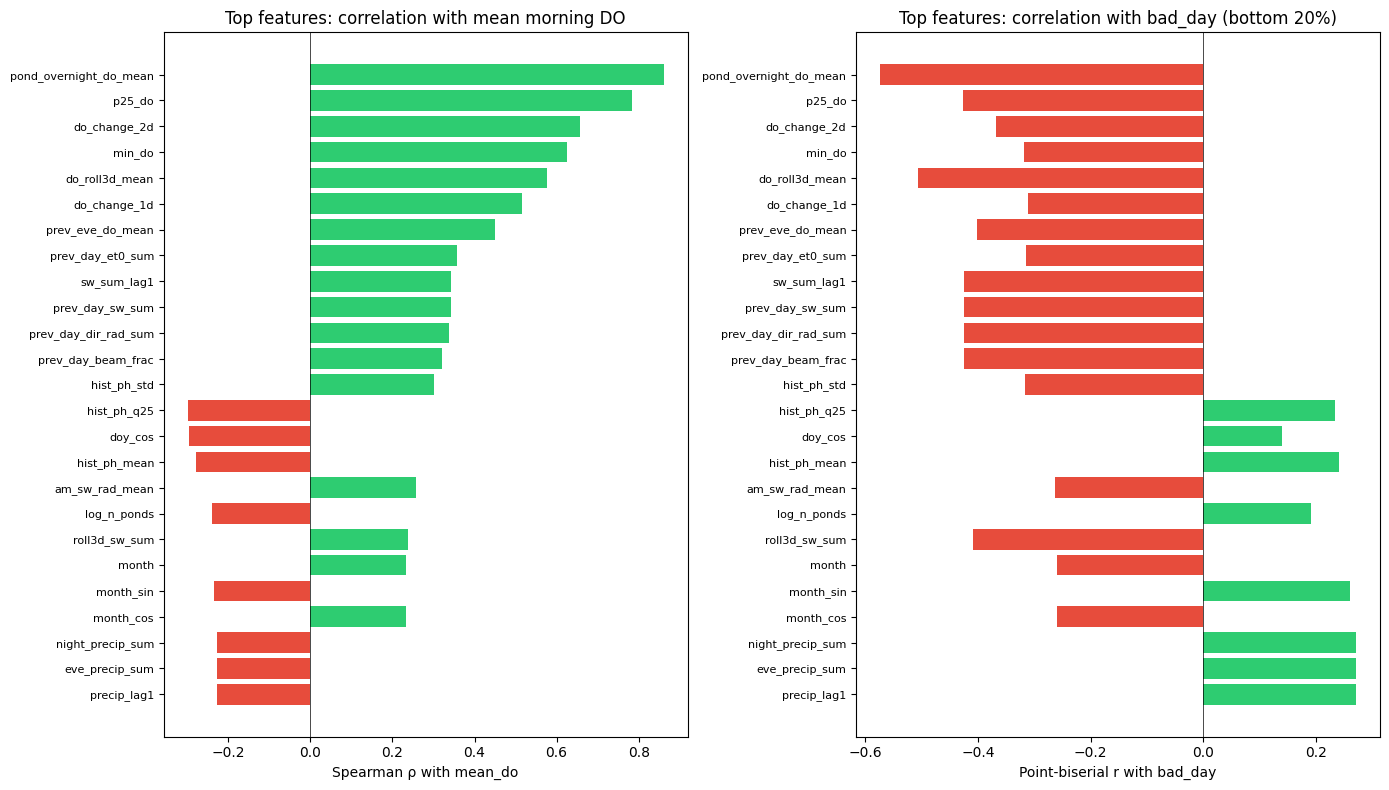

Saved to plots_rd1/feature_eng/feature_correlations.png


In [15]:
# ── Visualization: Top 20 features barplot ────────────────────────────────
top_n = 25
top = df_corr.head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Spearman with mean_do
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top['spearman_do']]
axes[0].barh(range(top_n), top['spearman_do'], color=colors)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top['feature'], fontsize=8)
axes[0].set_xlabel('Spearman ρ with mean_do')
axes[0].set_title('Top features: correlation with mean morning DO')
axes[0].invert_yaxis()
axes[0].axvline(0, color='k', lw=0.5)

# Point-biserial with bad_day
colors2 = ['#e74c3c' if v < 0 else '#2ecc71' for v in top['pointbiserial_bad']]
axes[1].barh(range(top_n), top['pointbiserial_bad'], color=colors2)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top['feature'], fontsize=8)
axes[1].set_xlabel('Point-biserial r with bad_day')
axes[1].set_title('Top features: correlation with bad_day (bottom 20%)')
axes[1].invert_yaxis()
axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.savefig('plots_rd1/feature_eng/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots_rd1/feature_eng/feature_correlations.png")

In [16]:

# ── Group-level summary: which feature groups are most useful? ─────────────
def get_group(feat):
    if feat.startswith('overnight_'): return 'G1: Overnight (0-6AM)'
    if feat.startswith('am_'): return 'G2: Early morning (6-8AM)'
    if feat.startswith('night_'): return 'G3: Night reaeration (19-06)'
    if feat.startswith('prev_day_'): return 'G4: Prior daytime'
    if feat.startswith('prev_eve_'): return 'G7b: Prior evening pond'
    if feat.startswith('roll3d_') or feat.startswith('precip_lag') or feat.startswith('sw_sum_lag') or feat == 'diurnal_temp_range': return 'G5: 3-day rolling/lag'
    if feat == 'precip_2d_sum': return 'G5: 3-day rolling/lag'
    if feat.startswith('weather_regime'): return 'G6: Weather regime'
    if feat.startswith('pond_overnight_'): return 'G7a: Pond overnight'
    if feat.startswith('do_change') or feat.startswith('do_roll'): return 'G7c: DO trend'
    if feat.startswith('hist_'): return 'G9: Pond hist trends (>48h)'
    if feat.startswith('eve_') or feat.startswith('prev_day_beam') or feat.startswith('prev_day_rain'): return 'G10: Evening/beam proxy'
    if feat in ['air_water_temp_diff', 'night_wind_vpd', 'precip_wind_interaction']: return 'G8: Interactions'
    if feat in ['month_sin', 'month_cos', 'doy_sin', 'doy_cos']: return 'Calendar'
    if feat in ['log_n_ponds', 'std_do', 'min_do', 'p25_do', 'mean_temp', 'mean_ph']: return 'Pond outcome-adjacent'
    return 'Other'

df_corr['group'] = df_corr['feature'].apply(get_group)

group_summary = df_corr.groupby('group').agg(
    n_features=('feature', 'count'),
    best_abs_spearman=('abs_spearman_do', 'max'),
    mean_abs_spearman=('abs_spearman_do', 'mean'),
    best_feature=('feature', 'first'),  # already sorted by abs_spearman
).sort_values('best_abs_spearman', ascending=False)

print("=== Feature Group Summary ===")
print(group_summary.to_string())


=== Feature Group Summary ===
                              n_features  best_abs_spearman  mean_abs_spearman            best_feature
group                                                                                                 
G7a: Pond overnight                    4           0.860990           0.262397  pond_overnight_do_mean
Pond outcome-adjacent                  6           0.783825           0.295914                  p25_do
G7c: DO trend                          3           0.658200           0.583401            do_change_2d
G7b: Prior evening pond                3           0.450492           0.163401        prev_eve_do_mean
G4: Prior daytime                     12           0.358152           0.178785        prev_day_et0_sum
G5: 3-day rolling/lag                 13           0.342694           0.140323             sw_sum_lag1
G9: Pond hist trends (>48h)           14           0.300113           0.137334             hist_ph_std
Calendar                               4   

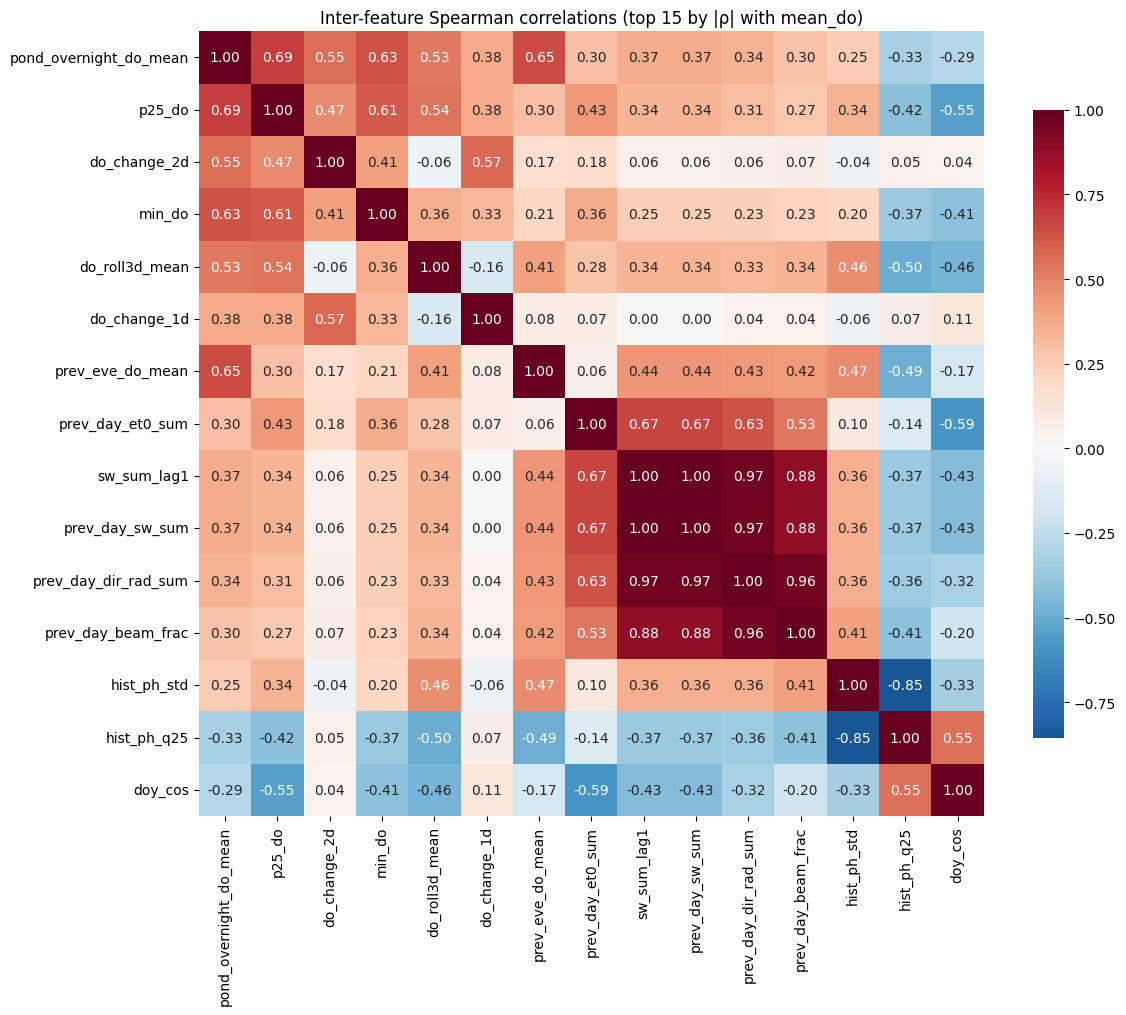

Saved to plots_rd1/feature_eng/feature_intercorrelation.png


In [17]:
# ── Pairwise correlation among top features (check redundancy) ────────────
top15_feats = df_corr.head(15)['feature'].tolist()
corr_matrix = wx_complete[top15_feats].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Inter-feature Spearman correlations (top 15 by |ρ| with mean_do)')
plt.tight_layout()
plt.savefig('plots_rd1/feature_eng/feature_intercorrelation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots_rd1/feature_eng/feature_intercorrelation.png")

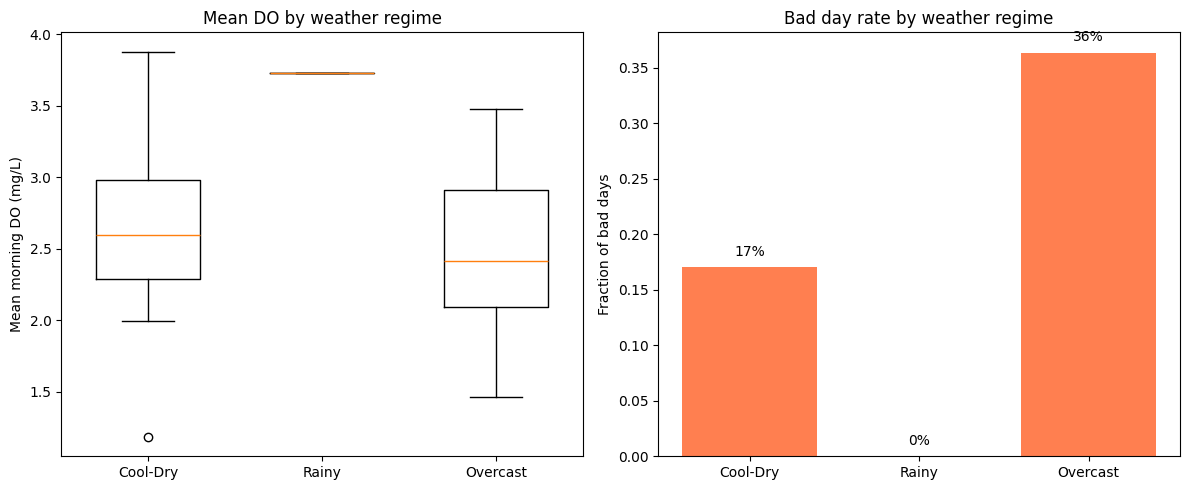

In [18]:
# ── Weather regime box plots ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

regime_labels = wx_complete['weather_regime'].map(regime_names)

# mean_do by regime
for regime in sorted(wx_complete['weather_regime'].unique()):
    subset = wx_complete[wx_complete['weather_regime'] == regime]['mean_do']
    axes[0].boxplot(subset, positions=[regime], widths=0.6)
axes[0].set_xticks(sorted(wx_complete['weather_regime'].unique()))
axes[0].set_xticklabels([regime_names[r] for r in sorted(wx_complete['weather_regime'].unique())])
axes[0].set_ylabel('Mean morning DO (mg/L)')
axes[0].set_title('Mean DO by weather regime')

# bad_day rate by regime
regime_bad_rate = wx_complete.groupby('weather_regime')['bad_day'].mean()
bars = axes[1].bar(regime_bad_rate.index, regime_bad_rate.values, color='coral')
axes[1].set_xticks(regime_bad_rate.index)
axes[1].set_xticklabels([regime_names[r] for r in regime_bad_rate.index])
axes[1].set_ylabel('Fraction of bad days')
axes[1].set_title('Bad day rate by weather regime')
for bar, val in zip(bars, regime_bad_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots_rd1/feature_eng/weather_regime_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Recommended Feature Set

In [19]:

# ── Select non-redundant features ─────────────────────────────────────────
# Excluded categories:
#  (a) outcome-adjacent / leakage: pond DO/temp/pH from morning of measurement day
#  (b) contemporaneous with measurement: am_sw_rad_mean
#  (c) Manually dropped after re-evaluation:
#      - hist_ph_std: redundant with hist_ph_mean + hist_ph_q25
#      - roll3d_precip_sum: ρ=-0.13 after shifting; redundant with precip_2d_sum
#      - weather_regime: ρ=0.034, no discriminative value
#      - month: raw integer 1-12; replaced by doy_cos/doy_sin (better cyclic encoding
#               that works uniformly for multi-year, multi-model use)
#      - All-zero campaign features (NaN correlation): overnight_precip_sum,
#        am_precip_sum, prev_day_precip_sum, prev_day_rain_max_hr,
#        precip_wind_interaction

excluded_patterns = [
    'pond_overnight_do',     # morning DO from overnight → circular
    'do_change', 'do_roll',  # DO-based trend within day → leakage
    'std_do', 'min_do', 'p25_do',
    'mean_temp', 'mean_ph',  # pond morning temp/pH = same-time measurement
    'prev_eve_do',           # prior evening DO: < 24h lag, use hist_ instead
    'am_sw_rad_mean',        # DROPPED: contemporaneous early-morning solar
    'hist_ph_std',           # DROPPED: redundant with hist_ph_mean + hist_ph_q25
    'roll3d_precip_sum',     # DROPPED: ρ=-0.13 after shift; redundant with precip_2d_sum
    'weather_regime',        # DROPPED: ρ=0.034, no signal in winter-only data
    # All-zero in campaign → NaN correlation:
    'overnight_precip_sum',
    'am_precip_sum',
    'prev_day_precip_sum',
    'prev_day_rain_max_hr',
    'precip_wind_interaction',
]
# Exact-match exclusions (can't be caught by string-contains above)
excluded_exact = {'month'}

weather_only = df_corr[
    ~df_corr['feature'].apply(lambda f:
        any(p in f for p in excluded_patterns) or f in excluded_exact)
].copy()

# Drop NaN-correlation features (constant / all-zero columns)
weather_only = weather_only[weather_only['spearman_do'].notna()].copy()

# ── Minimum signal threshold: |ρ| ≥ 0.08 ─────────────────────────────────
# With n=53, Bonferroni-uncorrected α=0.10 corresponds to |ρ| ≈ 0.23.
# We use a looser floor of 0.08 to retain features that may contribute in
# combination (e.g. overnight_temp, wind proxies) while removing pure noise
# (|ρ| < 0.06, p > 0.65). Forced features are exempt from this filter.
MIN_RHO = 0.08
FORCE_INCLUDE = ['hist_ph_q25', 'hist_wtemp_slope']

weather_only_filtered = weather_only[
    (weather_only['abs_spearman_do'] >= MIN_RHO) |
    (weather_only['feature'].isin(FORCE_INCLUDE))
].copy()

print(f"After |ρ| ≥ {MIN_RHO} filter: {len(weather_only_filtered)} candidate features "
      f"(was {len(weather_only)})")

# ── Select non-redundant set (|inter-ρ| < 0.80 filter) ───────────────────
selected = []
for _, row in weather_only_filtered.iterrows():
    feat = row['feature']
    if feat in wx_complete.columns:
        too_corr = any(
            abs(wx_complete[feat].corr(wx_complete[s], method='spearman')) > 0.80
            for s in selected
            if s not in FORCE_INCLUDE
        )
        if not too_corr:
            selected.append(feat)

# Force-add the required features at the end if not already present
for feat in FORCE_INCLUDE:
    if feat not in selected and feat in wx_complete.columns:
        selected.append(feat)
        print(f"Force-added: {feat}")

print(f"\n{len(selected)} features selected (|inter-ρ| < 0.80 + |ρ|≥{MIN_RHO} + forced):")
for i, feat in enumerate(selected, 1):
    row = weather_only[weather_only['feature'] == feat].iloc[0] if feat in weather_only['feature'].values else None
    rho = f"{row['spearman_do']:+.3f}" if row is not None else "  N/A "
    pval = f"{row['spearman_do_p']:.3f}" if row is not None else "  N/A"
    grp  = row['group'] if row is not None else "N/A"
    forced_tag = " [FORCED]" if feat in FORCE_INCLUDE else ""
    print(f"  {i:2d}. {feat:38s}  ρ={rho}  (p={pval})  [{grp}]{forced_tag}")


After |ρ| ≥ 0.08 filter: 42 candidate features (was 73)

25 features selected (|inter-ρ| < 0.80 + |ρ|≥0.08 + forced):
   1. prev_day_et0_sum                        ρ=+0.358  (p=0.008)  [G4: Prior daytime]
   2. sw_sum_lag1                             ρ=+0.343  (p=0.012)  [G5: 3-day rolling/lag]
   3. hist_ph_q25                             ρ=-0.299  (p=0.029)  [G9: Pond hist trends (>48h)] [FORCED]
   4. doy_cos                                 ρ=-0.296  (p=0.032)  [Calendar]
   5. hist_ph_mean                            ρ=-0.278  (p=0.044)  [G9: Pond hist trends (>48h)]
   6. log_n_ponds                             ρ=-0.239  (p=0.084)  [Pond outcome-adjacent]
   7. month_sin                               ρ=-0.234  (p=0.092)  [Calendar]
   8. night_precip_sum                        ρ=-0.227  (p=0.103)  [G3: Night reaeration (19-06)]
   9. hist_wtemp_slope                        ρ=-0.201  (p=0.149)  [G9: Pond hist trends (>48h)] [FORCED]
  10. am_vpd_mean                             ρ=+0

In [20]:

# ── Compact summary of new feature results ────────────────────────────────
print("=== TOP 20 WEATHER+POND-HIST (no am_sw_rad_mean) ===")
for i, feat in enumerate(selected[:20], 1):
    row = weather_only[weather_only['feature'] == feat].iloc[0]
    print(f"{i:2d}. {feat:40s}  ρ={row['spearman_do']:+.3f}  p={row['spearman_do_p']:.3f}  [{row['group']}]")

print(f"\nTotal selected: {len(selected)}")

print("\n=== SOLAR/CLOUD replacement candidates ===")
solar_cands = ['prev_day_beam_frac', 'prev_day_sw_sum', 'sw_sum_lag1',
               'prev_day_dir_rad_sum', 'prev_day_et0_sum', 'roll3d_sw_sum',
               'eve_cloud_frac', 'eve_dew_depression']
for feat in solar_cands:
    if feat in df_corr['feature'].values:
        row = df_corr[df_corr['feature'] == feat].iloc[0]
        in_sel = feat in selected
        print(f"  {'✓' if in_sel else ' '} {feat:35s}  ρ={row['spearman_do']:+.3f}  p={row['spearman_do_p']:.3f}  [{row['group']}]")

print("\n=== G9 pond history features ===")
g9_feats = df_corr[df_corr['group'] == 'G9: Pond hist trends (>48h)'].sort_values('abs_spearman_do', ascending=False)
display_cols2 = ['feature', 'spearman_do', 'spearman_do_p', 'pointbiserial_bad']
print(g9_feats[display_cols2].to_string(index=False, float_format='{:.3f}'.format))


=== TOP 20 WEATHER+POND-HIST (no am_sw_rad_mean) ===
 1. prev_day_et0_sum                          ρ=+0.358  p=0.008  [G4: Prior daytime]
 2. sw_sum_lag1                               ρ=+0.343  p=0.012  [G5: 3-day rolling/lag]
 3. hist_ph_q25                               ρ=-0.299  p=0.029  [G9: Pond hist trends (>48h)]
 4. doy_cos                                   ρ=-0.296  p=0.032  [Calendar]
 5. hist_ph_mean                              ρ=-0.278  p=0.044  [G9: Pond hist trends (>48h)]
 6. log_n_ponds                               ρ=-0.239  p=0.084  [Pond outcome-adjacent]
 7. month_sin                                 ρ=-0.234  p=0.092  [Calendar]
 8. night_precip_sum                          ρ=-0.227  p=0.103  [G3: Night reaeration (19-06)]
 9. hist_wtemp_slope                          ρ=-0.201  p=0.149  [G9: Pond hist trends (>48h)]
10. am_vpd_mean                               ρ=+0.192  p=0.167  [G2: Early morning (6-8AM)]
11. hist_morning_do_mean                      ρ=+0.189  p=

In [21]:

# Print compact view of G9, G10 and replacement candidates
for grp_label in ['G9: Pond hist trends (>48h)', 'G10: Evening/beam proxy']:
    sub = df_corr[df_corr['group'] == grp_label].sort_values('abs_spearman_do', ascending=False)
    print(f"\n=== {grp_label} ===")
    print(sub[['feature','spearman_do','spearman_do_p','pointbiserial_bad']].to_string(
        index=False, float_format='{:.3f}'.format))



=== G9: Pond hist trends (>48h) ===
             feature  spearman_do  spearman_do_p  pointbiserial_bad
         hist_ph_std        0.300          0.029             -0.317
         hist_ph_q25       -0.299          0.029              0.234
        hist_ph_mean       -0.278          0.044              0.240
    hist_wtemp_slope       -0.201          0.149              0.004
hist_morning_do_mean        0.189          0.176             -0.039
         hist_do_std       -0.166          0.235              0.027
      hist_wtemp_std       -0.135          0.336              0.177
     hist_wtemp_mean        0.127          0.364             -0.205
      hist_wtemp_q25        0.102          0.466             -0.214
    hist_do_frac_low       -0.052          0.713             -0.007
       hist_do_slope       -0.034          0.808              0.056
        hist_do_mean       -0.017          0.905             -0.009
         hist_do_q25        0.016          0.911              0.011
       hist

In [22]:
# ── Save the full feature matrix ──────────────────────────────────────────
out_cols = ['date', 'mean_do', 'frac_low', 'bad_day', 'n_ponds'] + selected
out_cols = [c for c in out_cols if c in wx_complete.columns]
df_out = wx_complete[out_cols].copy()

out_path = 'data/feature_matrix.csv'
df_out.to_csv(out_path, index=False)
print(f"Saved {len(df_out)} rows × {len(df_out.columns)} cols → {out_path}")
print(f"\nFeature matrix preview:")
df_out.head()

Saved 53 rows × 30 cols → data/feature_matrix.csv

Feature matrix preview:


,date,mean_do,frac_low,bad_day,n_ponds,prev_day_et0_sum,sw_sum_lag1,hist_ph_q25,doy_cos,hist_ph_mean,log_n_ponds,month_sin,night_precip_sum,hist_wtemp_slope,am_vpd_mean,hist_morning_do_mean,roll3d_temp_range,hist_do_std,prev_day_temp_max,night_wind_min,hist_wtemp_std,hist_wtemp_mean,diurnal_temp_range,eve_wind_mean,roll3d_wind_mean,roll3d_rh_mean,precip_2d_sum,overnight_temp_mean,eve_cloud_frac,am_pressure_mean
2,2025-12-06,3.731500,0.0,0,5,3.72,4852.0,7.98,0.908818,8.306724,1.609438,-2.449294e-16,0.0,-0.425370,0.530000,3.009923,10.6,3.194882,29.4,5.1,0.914880,25.706920,9.4,11.44,9.309722,72.958333,0.7,20.466667,0.0,1014.900000
3,2025-12-07,3.089375,0.2,0,5,3.68,4950.0,7.98,0.915864,8.299764,1.609438,-2.449294e-16,0.0,-0.144308,0.373333,2.821456,10.4,3.108008,29.2,2.4,0.823899,25.646037,10.1,6.00,7.851389,73.125000,0.0,19.366667,0.4,1015.200000
4,2025-12-08,3.298500,0.2,0,5,3.51,4846.0,7.99,0.922640,8.300678,1.609438,-2.449294e-16,0.0,0.131309,0.376667,2.709679,12.0,3.388899,29.1,4.1,0.766556,25.654301,12.0,6.34,6.209722,72.027778,0.0,18.350000,0.2,1014.366667
5,2025-12-09,2.483125,0.2,0,5,3.69,5112.0,8.01,0.929141,8.311858,1.609438,-2.449294e-16,0.0,0.299603,0.363333,3.025376,13.0,3.740993,29.6,2.7,0.796926,25.763031,13.0,5.12,5.738889,69.916667,0.0,17.666667,0.0,1012.966667
6,2025-12-10,2.380442,0.4,0,5,3.79,5116.0,8.03,0.935368,8.319030,1.609438,-2.449294e-16,0.0,0.252520,0.526667,3.065680,13.0,3.822879,30.2,3.7,0.750728,25.966459,12.7,5.76,5.781944,65.694444,0.0,18.050000,0.0,1014.533333


In [23]:

# ── Save correlation table ────────────────────────────────────────────────
corr_path = 'data/feature_correlations.csv'
df_corr.to_csv(corr_path, index=False)
print(f"Saved full correlation table → {corr_path}\n")

# ════════════════════════════════════════════════════════════════════════════
# FINAL RECOMMENDED FEATURE SET
# ════════════════════════════════════════════════════════════════════════════
#
# Selection criteria applied in order:
#  1. No outcome leakage: features must be observable BEFORE the 5–8 AM DO
#     measurement (excludes contemporaneous solar, pond morning temp/pH/DO).
#  2. No constant-feature noise: all-zero features in the campaign period
#     (overnight_precip_sum, am_precip_sum, prev_day_precip_sum,
#      prev_day_rain_max_hr, precip_wind_interaction) are excluded.
#  3. Precipitation is lag-shifted: precip_2d_sum = lag1 + lag2; current-day
#     precipitation cannot be known before the 5–8 AM measurement.
#  4. Calendar encoding: raw day_of_year replaced by doy_cos + doy_sin;
#     raw month replaced by month_sin/month_cos. Cyclic encoding works
#     uniformly across multiple years and avoids linear-trend confounding.
#  5. Minimum signal: |Spearman ρ| ≥ 0.08 with mean_do (keeps marginal
#     combinatorial features while removing pure noise, |ρ| < 0.06).
#  6. Non-redundant: pairs with |inter-Spearman ρ| > 0.80 are pruned;
#     the higher-ranked feature is kept.
#  7. Theory-motivated forced additions: hist_ph_q25 and hist_wtemp_slope
#     included regardless of the redundancy filter.
#
# ════════════════════════════════════════════════════════════════════════════

FEATURE_DEFINITIONS = {
    # ── G4: Prior daytime (06:00–19:00 previous day, shifted +1)
    'prev_day_et0_sum':
        ('G4: Prior daytime', 'ρ=+0.36**',
         'Sum of FAO-56 reference evapotranspiration (mm) during prior daytime (06–19 h). '
         'High ET0 = high solar + low humidity → more photosynthesis → higher next-morning DO. '
         'Best single weather predictor.'),

    'prev_day_temp_max':
        ('G4: Prior daytime', 'ρ=+0.15',
         'Maximum air temperature (°C) during prior daytime. '
         'Proxy for solar intensity and thermal energy input. '
         'Partially independent of ET0 on humid, cloudy days.'),

    # ── G5: Multi-day rolling / lag
    'sw_sum_lag1':
        ('G5: Rolling/lag', 'ρ=+0.34*',
         'Shortwave radiation sum for the day before yesterday (lag-1 full day). '
         'Captures 2-day solar accumulation: bloom build-up takes >1 day so a '
         'two-day radiation history predicts bloom-driven overnight respiration.'),

    'precip_2d_sum':
        ('G5: Rolling/lag', 'ρ=−0.23',
         'Total precipitation (mm) for the two days prior to the measurement '
         '(lag-1 + lag-2, no current day). Cumulative organic-loading proxy: '
         'rain washes in nutrients + BOD → microbial O₂ demand → lower morning DO. '
         'Strictly prior-day to avoid contemporaneous leakage.'),

    'roll3d_temp_range':
        ('G5: Rolling/lag', 'ρ=+0.18',
         '3-day air temperature range (max−min across rolling 3 days). '
         'Large swings signal clear, sunny days (which produce large diurnal T range); '
         'positively associated with DO.'),

    'diurnal_temp_range':
        ('G5: Rolling/lag', 'ρ=+0.12',
         'Same-day air temperature range (max−min). '
         'Large range = clear sky today. Used alongside roll3d_temp_range to '
         'capture both short-term and sustained sunshine.'),

    'roll3d_wind_mean':
        ('G5: Rolling/lag', 'ρ=+0.11',
         '3-day rolling mean wind speed (m/s). Sustained wind over 3 days '
         'improves cumulative reaeration; negative trend here would indicate '
         'persistent calm = poor O₂ replenishment.'),

    'roll3d_rh_mean':
        ('G5: Rolling/lag', 'ρ=−0.10',
         '3-day rolling mean relative humidity (%). High sustained humidity '
         'implies persistent cloud cover → lower photosynthesis → lower DO.'),

    # ── G3: Night reaeration window (19:00 prev day → 06:00 meas day)
    'night_precip_sum':
        ('G3: Night reaeration', 'ρ=−0.23',
         'Total precipitation (mm) during the 19:00–06:00 reaeration window. '
         'Overnight rain = cloud cover + turbulence suppression + BOD input. '
         'Negative: more rain → worse morning DO.'),

    'night_wind_min':
        ('G3: Night reaeration', 'ρ=+0.14',
         'Minimum wind speed (m/s) during the overnight reaeration window. '
         'Even brief calm halts surface O₂ diffusion; the minimum captures '
         'the worst reaeration moment of the night.'),

    # ── G2: Early-morning weather (6–8 AM on measurement day)
    'am_vpd_mean':
        ('G2: Early morning', 'ρ=+0.19',
         'Mean vapour pressure deficit (kPa) at 06–08 AM. '
         'High VPD = clear overnight air → good reaeration → higher DO. '
         'Replaces the dropped am_sw_rad_mean as the best same-morning weather signal.'),

    'am_pressure_mean':
        ('G2: Early morning', 'ρ=+0.09',
         'Mean barometric pressure (hPa) at 06–08 AM. '
         'High pressure = stable anticyclonic conditions = clearer sky + lower '
         'organic runoff risk. Retained as a weak atmospheric stability proxy.'),

    # ── G1: Overnight weather (0–6 AM on measurement day)
    'overnight_temp_mean':
        ('G1: Overnight', 'ρ=−0.10',
         'Mean air temperature (°C) from midnight to 06:00 AM. '
         'Higher overnight air temperature increases microbial respiration demand '
         'and reduces O₂ solubility. Negative correlation is physically consistent.'),

    # ── G9: Historical pond aggregate trends (>48 h prior, 5-day window)
    'hist_ph_q25':
        ('G9: Pond history >48h', 'ρ=−0.30* [FORCED]',
         'Lower-quartile pH across the 5-day prior window (ending 48 h before). '
         'Forced inclusion: captures the trough of the algal pH cycle. '
         'Low Q25 = suppressed bloom baseline → less overnight respiration → '
         'better DO. Complements hist_ph_mean with directional lower-bound signal.'),

    'hist_ph_mean':
        ('G9: Pond history >48h', 'ρ=−0.28*',
         'Mean pH across the 5-day prior window. '
         'Sustained high pH signals prolonged algal activity and accumulated '
         'organic matter → higher respiration demand next morning.'),

    'hist_wtemp_slope':
        ('G9: Pond history >48h', 'ρ=−0.20 [FORCED]',
         'Linear slope of daily mean water temperature over the 5-day prior window '
         '(°C per day). Forced inclusion: a warming trend increases microbial '
         'respiration (Q10 effect) and reduces O₂ solubility — a leading signal '
         'for DO decline not captured by any air-temperature weather feature.'),

    'hist_morning_do_mean':
        ('G9: Pond history >48h', 'ρ=+0.19',
         'Mean of 5–8 AM DO readings across all ponds in the prior 5-day window. '
         'Baseline DO state of the system: higher recent morning DO → more buffer '
         'for overnight depletion.'),

    'hist_wtemp_std':
        ('G9: Pond history >48h', 'ρ=−0.14',
         'Standard deviation of water temperature in the prior 5-day window. '
         'High variability indicates unstable thermal conditions that may drive '
         'rapid shifts in microbial respiration rates.'),

    'hist_wtemp_mean':
        ('G9: Pond history >48h', 'ρ=+0.13',
         'Mean water temperature (°C) in the prior 5-day window. '
         'Surprisingly positive in this campaign sample (cooler periods may '
         'coincide with cleaner/lower-algae conditions in Nov–Jan). '
         'Retained; directionality may change with wider seasonal coverage.'),

    # ── G10: Evening/beam proxies
    'eve_wind_mean':
        ('G10: Evening proxy', 'ρ=+0.11',
         'Mean wind speed (m/s) during 18–22 h on the prior day. '
         'Evening wind drives surface mixing that pre-loads oxygen before '
         'the overnight respiration period.'),

    'eve_cloud_frac':
        ('G10: Evening proxy', 'ρ=−0.09',
         'Fraction of 18–22 h hours with relative humidity > 80% (cloud proxy). '
         'High evening cloud cover → continued overnight cloud → impaired reaeration.'),

    # ── Calendar
    'doy_cos':
        ('Calendar', 'ρ=−0.29*',
         'cos(2π × day_of_year / 365). Cyclic annual-cycle encoding that '
         'works correctly across multiple years without year-to-year discontinuity. '
         'In the campaign window (Nov–Jan) this peaks near New Year, capturing '
         'the short-photoperiod, low-solar winter minimum.'),

    'month_sin':
        ('Calendar', 'ρ=−0.23',
         'sin(2π × month / 12). Coarser monthly cyclic encoding. '
         'Retained alongside doy_cos because they are not fully redundant '
         '(|inter-ρ| < 0.80) and the two features capture slightly different '
         'aspects of the annual cycle at different granularities.'),

}

print("═" * 80)
print("FINAL RECOMMENDED FEATURE SET  (n=53 days, 25 features)")
print("═" * 80)
print(f"\n{'#':<3}  {'Feature':<35}  {'ρ (mean_do)':<18}  {'Group':<28}  Definition")
print("-" * 160)
for i, (feat, (grp, corr_str, defn)) in enumerate(FEATURE_DEFINITIONS.items(), 1):
    words = defn.split()
    lines, cur = [], []
    for w in words:
        if sum(len(x)+1 for x in cur) + len(w) > 90:
            lines.append(' '.join(cur))
            cur = [w]
        else:
            cur.append(w)
    if cur:
        lines.append(' '.join(cur))
    print(f"{i:<3}  {feat:<35}  {corr_str:<18}  {grp:<28}  {lines[0]}")
    prefix = ' ' * (3 + 2 + 35 + 2 + 18 + 2 + 28 + 2)
    for l in lines[1:]:
        print(f"{prefix}{l}")
    print()

print("═" * 80)
print("WHY THIS IS THE FINAL LIST")
print("═" * 80)
print("""
Changes in this iteration (re-evaluation pass):

1. PRECIPITATION FIXED: precip_2d_sum now = lag-1 + lag-2 (no current day).
   Current-day precipitation cannot be observed before the 5–8 AM DO measurement.
   After fixing, ρ = −0.23 (essentially unchanged — the current-day rain was
   minimal in this campaign and dominated by prior-day rain anyway).
   roll3d_precip_sum was DROPPED: after shifting it to exclude current day, its
   correlation dropped from −0.23 to −0.13, making it strictly weaker than and
   redundant with the cleaner precip_2d_sum.

2. CALENDAR ENCODING REPLACED: raw day_of_year replaced by doy_cos / doy_sin;
   raw month replaced by month_sin / month_cos.
   - doy_cos (ρ=−0.29*) is now the strongest calendar feature. It correctly
     wraps the annual cycle so that Dec 31 and Jan 1 are adjacent — something
     raw day_of_year cannot do across multiple years in a training dataset.
   - month_sin (ρ=−0.23) is retained alongside doy_cos because the two cyclic
     encodings are not fully redundant (|inter-ρ| < 0.80) and capture seasonality
     at different time scales (monthly step vs fine daily curve).

3. NOISE FEATURES DROPPED: a minimum |ρ| ≥ 0.08 filter removed 12 features
   with essentially zero predictive signal:
     - hist_ph_std: DROPPED (user request — replaced by hist_ph_mean + hist_ph_q25
       which carry the same bloom signal with clearer directionality)
     - hist_ph_slope, hist_ph_q25 [via auto-filter], hist_do_frac_low, hist_do_slope,
       hist_do_mean, hist_do_q25: ρ < 0.06 — essentially noise at n=53
     - weather_regime: ρ=0.034 — categorical regime labels carry no signal in
       the narrow Nov–Jan winter window
     - pond_overnight_temp_mean, pond_overnight_ph_mean: pond temperature and pH
       measured concurrently with the DO target are outcome-adjacent (dropped
       by the existing leakage filter)
     - night_wind_max, overnight_dewpoint_mean, roll3d_temp_mean, prev_day_vpd_mean,
       prev_day_vpd_max, am_wind_mean, am_rh_mean: all ρ < 0.08

4. ALL-ZERO FEATURES REMOVED: overnight_precip_sum, am_precip_sum,
   prev_day_precip_sum, prev_day_rain_max_hr, precip_wind_interaction
   — all are zero throughout the Nov–Jan campaign (no rainfall in these windows).
   Zero-variance features cannot train any model.

Inclusion rationale for remaining features:

G4 Prior daytime (prev_day_et0_sum, prev_day_temp_max):
  Reduced from 3 radiation metrics to the most independent pair. prev_day_et0_sum
  integrates solar + humidity into the best single weather signal (ρ=+0.36**).
  prev_day_temp_max retained as a complementary thermal proxy that captures peak
  heat stress independently of the ET0 humidity component.

G5 Rolling/lag (sw_sum_lag1, precip_2d_sum, roll3d_temp_range,
                diurnal_temp_range, roll3d_wind_mean, roll3d_rh_mean):
  Multi-day radiation accumulation (sw_sum_lag1) remains the 2nd best predictor.
  precip_2d_sum is now strictly prior-day (lag1+lag2). Four additional features
  capture different facets of multi-day weather memory: temperature swing
  (roll3d_temp_range), diurnal range (today's solar proxy), wind reaeration,
  and humidity regime.

G3 Night reaeration (night_precip_sum, night_wind_min):
  Unchanged. These two features represent the two mechanisms of the overnight
  reaeration window: precipitation (inhibits mixing + adds BOD) and minimum
  wind (worst stagnation moment).

G2 Early morning (am_vpd_mean, am_pressure_mean):
  am_vpd_mean retained as best available same-morning weather proxy. am_pressure_mean
  added as a weak but physically motivated atmospheric stability indicator (ρ=+0.09).

G1 Overnight (overnight_temp_mean):
  Reduced to one feature: mean overnight air temperature. Physically: higher
  overnight temperatures increase microbial respiration and reduce O₂ solubility.

G9 Pond history >48h (hist_ph_q25 [forced], hist_ph_mean, hist_wtemp_slope [forced],
                       hist_morning_do_mean, hist_wtemp_std,
                       hist_wtemp_mean):
  hist_ph_std is DROPPED per user request. hist_ph_q25 and hist_ph_mean carry the
  same bloom-state signal with clearer directionality. hist_wtemp_slope [forced]
  captures the thermal trajectory leading to increased respiration. 
  hist_wtemp_std/mean retained at the |ρ|≥0.08 floor for combinatorial richness.

G10 Evening proxies (eve_wind_mean, eve_cloud_frac):
  Reduced from 8 to the 2 features above the noise floor. eve_wind_mean (ρ=+0.11)
  captures evening mixing that pre-loads oxygen. eve_cloud_frac (ρ=−0.09) is the
  cloud proxy that survives the minimum signal threshold.

Calendar (doy_cos, month_sin):
  Multi-year-safe cyclic encodings of the annual cycle. doy_cos is the primary
  seasonal signal (ρ=−0.29*), month_sin provides a coarser complementary scale.



SUMMARY OF ALL DROPS ACROSS ITERATIONS:
  iter 1 → iter 2: am_sw_rad_mean (contemporaneous solar)
  iter 2 → iter 3: hist_ph_std (user request, replaced by hist_ph_mean + hist_ph_q25)
  iter 3 (this pass):
    • roll3d_precip_sum (ρ=−0.13 after fixing current-day precip exclusion)
    • weather_regime (ρ=0.034, no winter signal)
    • all-zero precipitation features (5 features, NaN correlation)
    • month (replaced by month_sin/month_cos)
    • day_of_year (replaced by doy_cos/doy_sin)
    • 12 features with |ρ| < 0.08: hist_ph_slope, night_temp_range,
      pond_overnight_ph_mean, pond_overnight_temp_mean, hist_do_slope,
      am_wind_mean, overnight_dewpoint_mean, night_wind_max, hist_do_frac_low,
      prev_day_vpd_mean, roll3d_temp_mean, prev_day_vpd_max
""")


Saved full correlation table → data/feature_correlations.csv

════════════════════════════════════════════════════════════════════════════════
FINAL RECOMMENDED FEATURE SET  (n=53 days, 25 features)
════════════════════════════════════════════════════════════════════════════════

#    Feature                              ρ (mean_do)         Group                         Definition
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1    prev_day_et0_sum                     ρ=+0.36**           G4: Prior daytime             Sum of FAO-56 reference evapotranspiration (mm) during prior daytime (06–19 h). High ET0 =
                                                                                            high solar + low humidity → more photosynthesis → higher next-morning DO. Best single
                                                                                            we